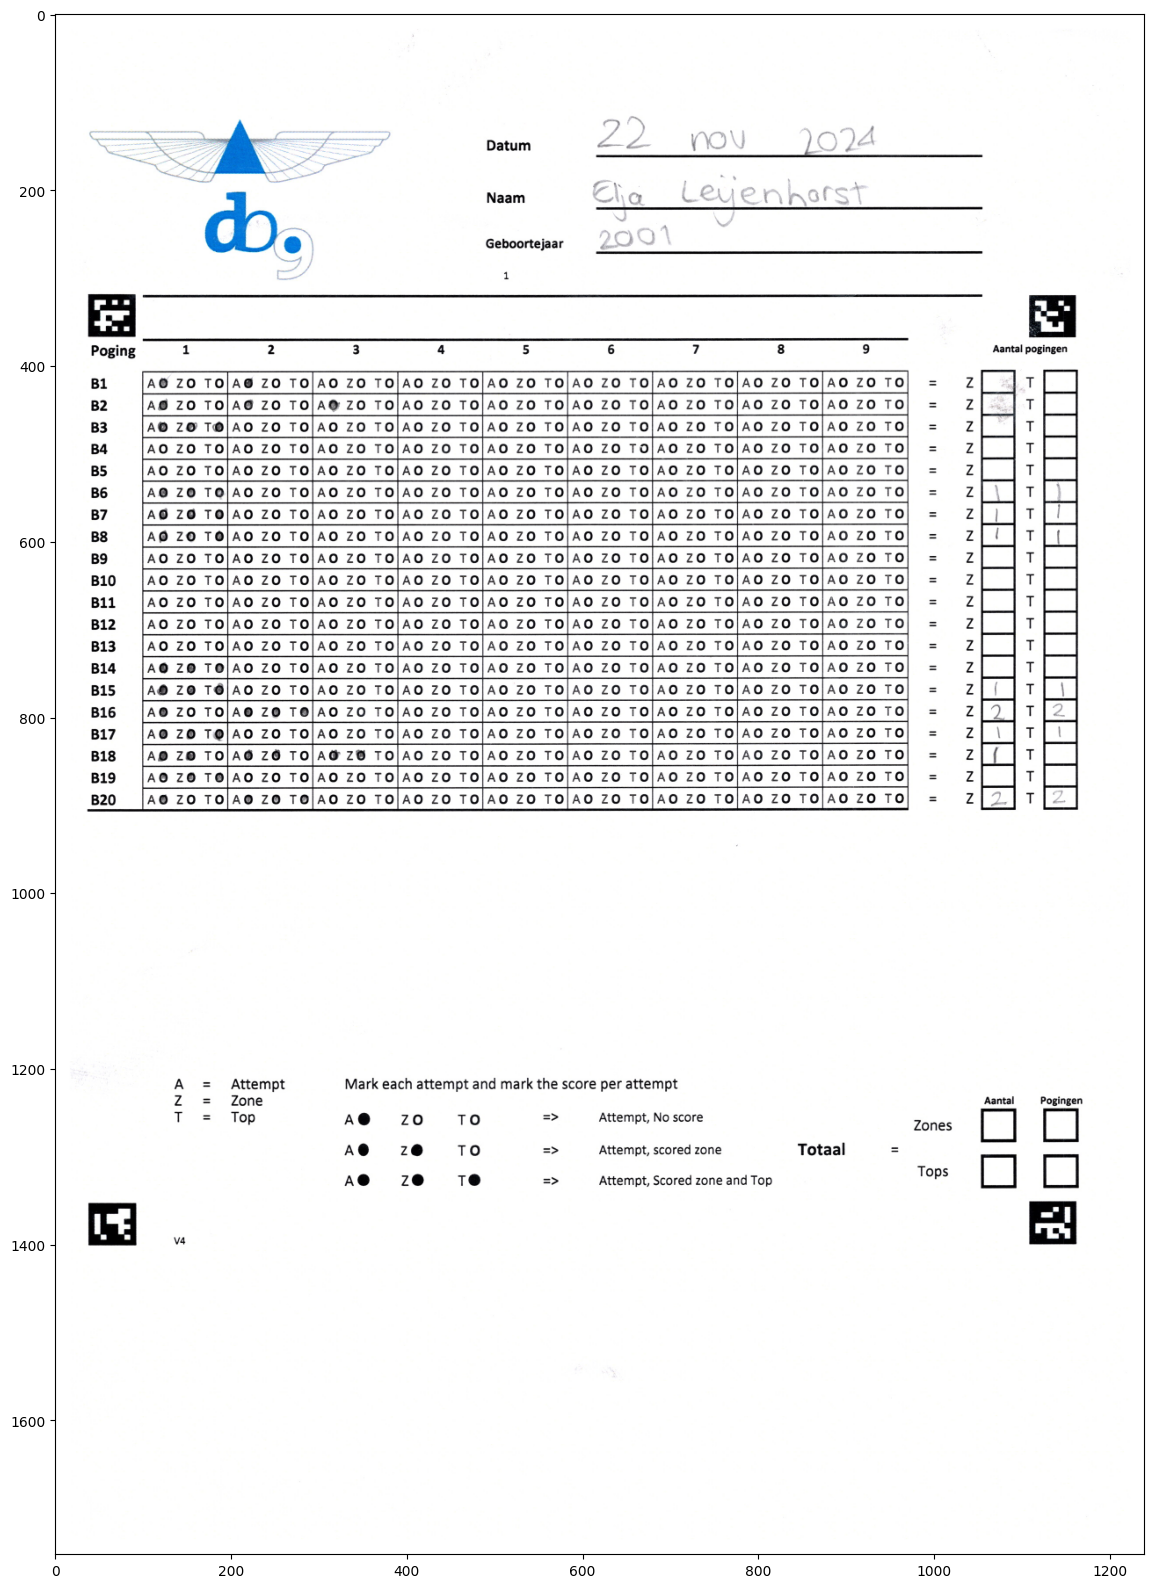

In [17]:
# STEP 1: Setup & file reading
import os
import cv2
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Source file is the first png or jpg file in the source_file/ directory
source_file = None
for filename in os.listdir("config_generator_source/"):
	if filename.endswith((".png", ".jpg")):
		source_file = os.path.join("config_generator_source/", filename)
		break

if source_file is None:
	raise FileNotFoundError("No image file found in source_file/ directory.")

# Display the source file, filling the width of the notebook
source_img_bgr = cv2.imread(source_file)
source_img_bgr = cv2.resize(source_img_bgr, (0, 0), fx=0.5, fy=0.5)
source_img = cv2.cvtColor(source_img_bgr, cv2.COLOR_BGR2GRAY)
source_img_rgb = cv2.cvtColor(source_img_bgr, cv2.COLOR_BGR2RGB)
source_img_rgb = np.array(source_img_rgb, dtype=np.uint8)
source_img = np.array(source_img, dtype=np.uint8)
plt.figure(figsize=(20, 20))
plt.imshow(source_img_rgb, vmin=0, vmax=255)

Please check that all the markers are detected correctly. If not, adjust the parameters in aruco_handler.py and re-run this notebook.
[(64, 343), (1134, 343), (1134, 1375), (64, 1377)]


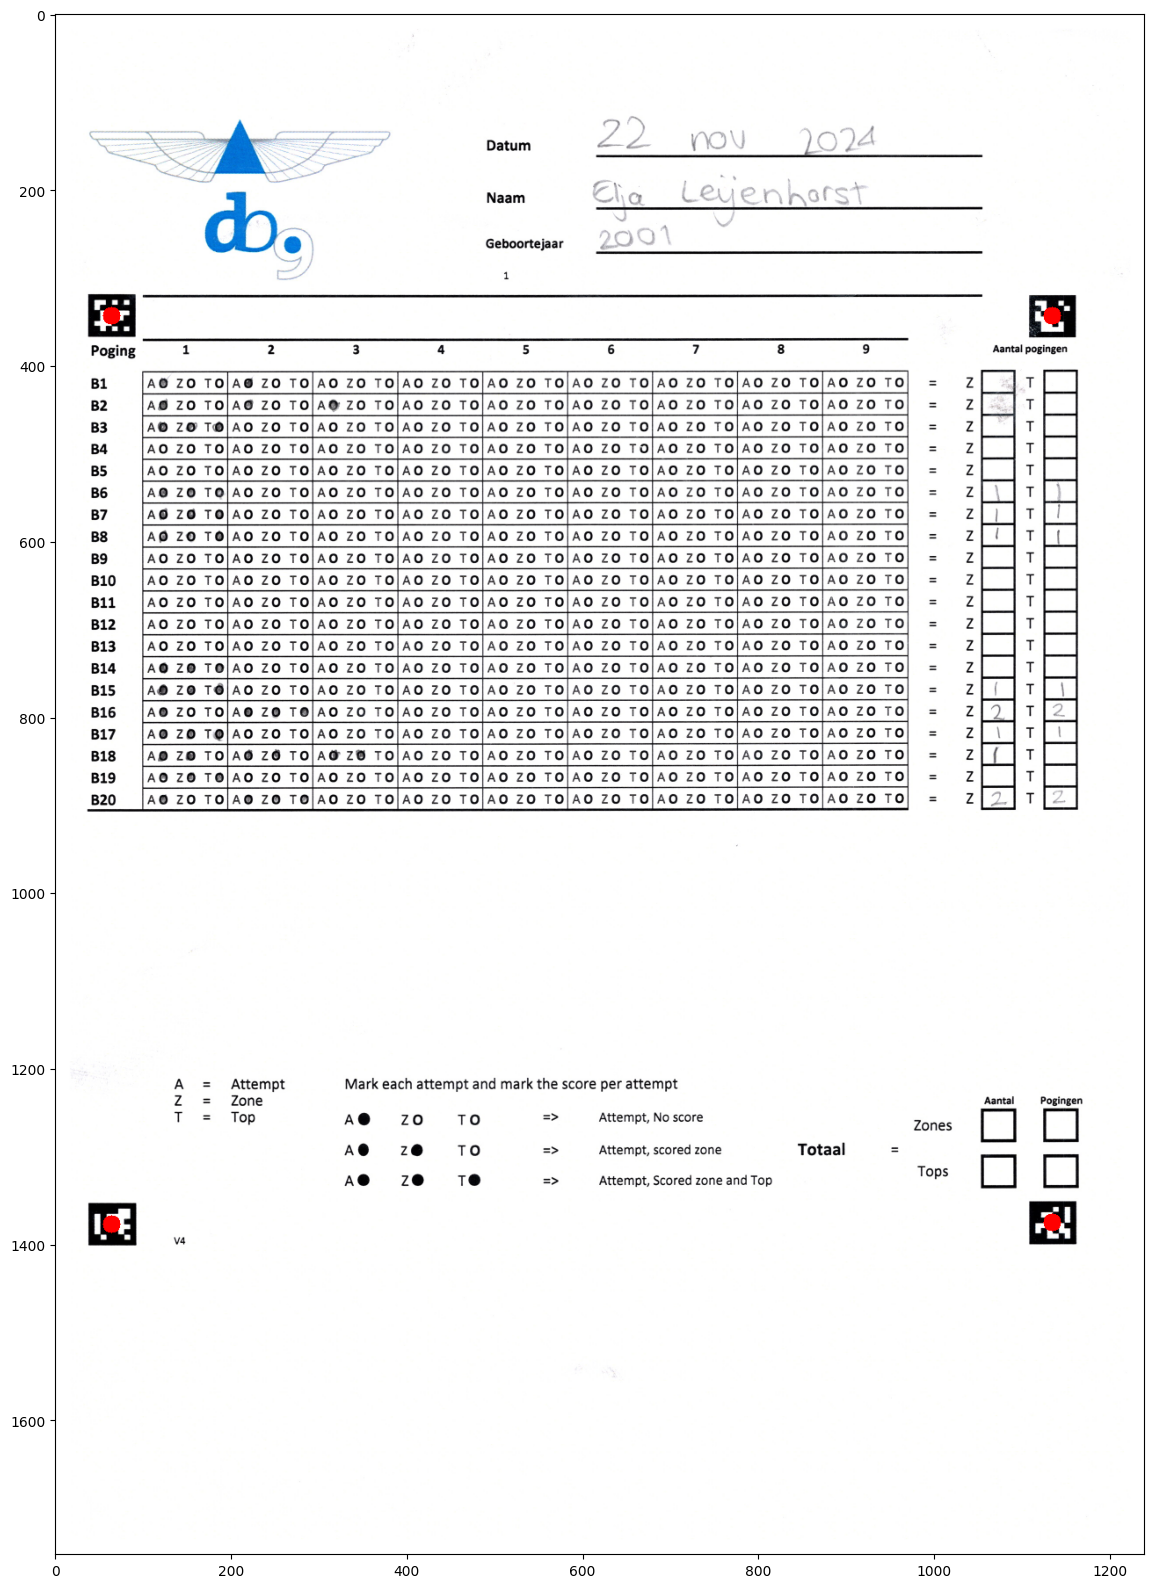

In [18]:
# Step 2: Finding the ARUCO markers
import aruco_handler

print("Please check that all the markers are detected correctly. If not, adjust the parameters in aruco_handler.py and re-run this notebook.")

marker_centers = aruco_handler.detect_aruco_markers(source_img_rgb)

source_img_with_markers = source_img_rgb.copy()

# Draw the marker centers on the image
print(marker_centers)
for center in marker_centers:
	cv2.circle(source_img_with_markers, center, 10, (255, 0, 0), -1)

plt.figure(figsize=(20, 20))
plt.imshow(source_img_with_markers)

Please select the region for: user_info
Selected region for user_info: ((601, 106), (1067, 280))
Please select the region for: attempt_score
Selected region for attempt_score: ((100, 407), (971, 905))
Please select the region for: boulder_score
Selected region for boulder_score: ((1031, 401), (1221, 907))
Please select the region for: total_scores
Selected region for total_scores: ((978, 1203), (1222, 1374))
All regions selected.
Selected regions: {'user_info': ((601, 106), (1067, 280)), 'attempt_score': ((100, 407), (971, 905)), 'boulder_score': ((1031, 401), (1221, 907)), 'total_scores': ((978, 1203), (1222, 1374))}
Selected regions (relative coordinates): {'user_info': ((np.float64(0.5018691588785047), np.float64(-0.22920696324951645)), (np.float64(0.9373831775700935), np.float64(-0.0609284332688588))), 'attempt_score': ((np.float64(0.03364485981308411), np.float64(0.061895551257253385)), (np.float64(0.8476635514018691), np.float64(0.5435203094777563))), 'boulder_score': ((np.float6

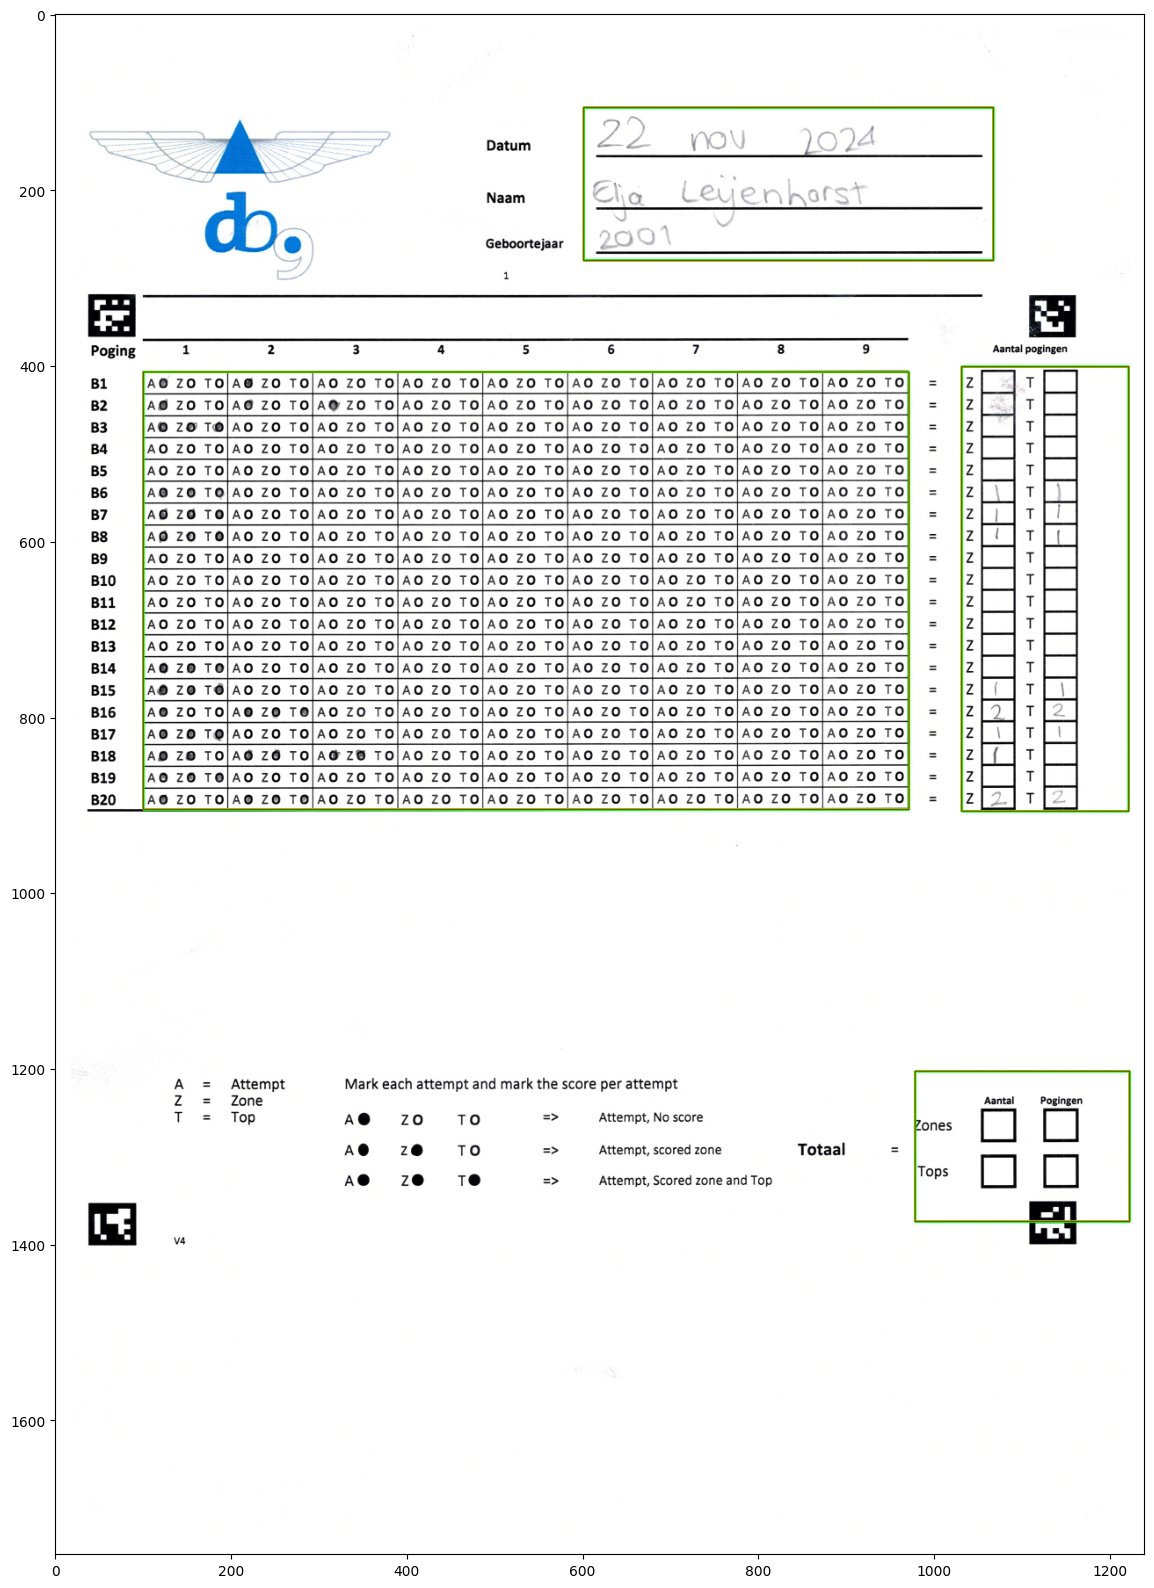

In [19]:
# Step 3: Selecting the regions of interest (ROIs)

# State
drawing = False
start = (0, 0)
end = (0, 0)

source_img_rgb_copy = source_img_rgb.copy()

regions_to_select = ["user_info", "attempt_score", "boulder_score", "total_scores"]
regions = {}
current_region_index = 0

def mouse_callback(event, x, y, flags, param):
	global drawing, start, end, current_region_index

	if event == cv2.EVENT_LBUTTONDOWN:
		drawing = True
		start = (x, y)
		end = (x, y)

	elif event == cv2.EVENT_MOUSEMOVE and drawing:
		end = (x, y)

	elif event == cv2.EVENT_LBUTTONUP:
		drawing = False
		end = (x, y)
		x1, y1 = min(start[0], end[0]), min(start[1], end[1])
		x2, y2 = max(start[0], end[0]), max(start[1], end[1])

		cv2.rectangle(source_img_rgb_copy, start, end, (0, 255, 0), 2)

		regions[regions_to_select[current_region_index]] = (start, end)
		print(f"Selected region for {regions_to_select[current_region_index]}: {(start, end)}")

		current_region_index += 1
		if current_region_index < len(regions_to_select):
			print(f"Please select the region for: {regions_to_select[current_region_index]}")
		else:
			print("All regions selected.")

cv2.namedWindow("Select ROI")
cv2.setMouseCallback("Select ROI", mouse_callback)

print("Please select the region for:", regions_to_select[0])

while True:
	
	display = source_img_rgb_copy.copy()
	if drawing or (start != end):
		cv2.rectangle(display, start, end, (0, 255, 0), 2)
	cv2.imshow("Select ROI", display)

	key = cv2.waitKey(1) & 0xFF
	if key == ord("q") or current_region_index >= len(regions_to_select):
		break

cv2.destroyAllWindows()

print("Selected regions:", regions)

# Convert the regions to relative coordinates
for key in regions:
	start, end = regions[key]
	start_rel = aruco_handler.img_coord_to_relative_coords(start, marker_centers)
	end_rel = aruco_handler.img_coord_to_relative_coords(end, marker_centers)
	regions[key] = (start_rel, end_rel)

print("Selected regions (relative coordinates):", regions)

# Convert the relative coordinates back to confirm they are correct
for key in regions:
	start_rel, end_rel = regions[key]
	start_abs = aruco_handler.relative_coords_to_img_coord(start_rel, marker_centers)
	end_abs = aruco_handler.relative_coords_to_img_coord(end_rel, marker_centers)
	
	cv2.rectangle(display, start_abs, end_abs, (255, 0, 0), 1)
	
plt.figure(figsize=(20, 20))
plt.imshow(display)
print("The red rectangles are the final regions you selected. Please make sure they are correct. If not, adjust the parameters in aruco_handler.py and re-run this notebook.")


In [20]:
# Step 4: final manual information

# Will the OMR sheet use automatic name detection?
use_name_detection = input("Will the OMR sheet use automatic name detection? (Y/N): ").strip().upper() == "Y"

# Will the OMR sheet use automatic gender detection?
use_gender_detection = input("Will the OMR sheet use automatic gender detection? (Y/N): ").strip().upper() == "Y"

# Will the OMR sheet use automatic age detection?
use_age_detection = input("Will the OMR sheet use automatic age detection? (Y/N): ").strip().upper() == "Y"

# What is the name of this OMR sheet configuration? (e.g., "lead_climbing_sheet")
config_name = input("What is the name of this OMR sheet configuration?: ").strip()

In [21]:
# Step 5: Save the configuration
config = {
	"config_name": config_name,
	"use_name_detection": use_name_detection,
	"use_gender_detection": use_gender_detection,
	"use_age_detection": use_age_detection,
	"regions": regions,
}

filepath = os.path.join("configs", f"{config_name}.json")
os.makedirs("configs", exist_ok=True)
with open(filepath, "w") as f:
	json.dump(config, f, indent=4)